# Financial News Sentiment and Stock Correlation Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

# Load Financial News Dataset

In [2]:
news_df = pd.read_csv(
    "../Data/raw_analyst_ratings.csv"
)


In [3]:
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# Dataset Information

In [4]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


# Data Quality Checks

In [5]:
news_df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [6]:
news_df = news_df.dropna(
    subset=["headline", "date"]
)

# Datetime Processing

In [7]:
news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True
)

In [8]:
news_df["Date_Only"] = (
    news_df["date"].dt.date
)

# Sentiment Analysis Using TextBlob

In [9]:
news_df["Sentiment"] = (
    news_df["headline"].apply(
        lambda x:
        TextBlob(x).sentiment.polarity
    )
)

In [10]:
news_df[
    ["headline", "Sentiment"]
].head()

,headline,Sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.0
1,Stocks That Hit 52-Week Highs On Wednesday,0.0
2,71 Biggest Movers From Friday,0.0
3,46 Stocks Moving In Friday's Mid-Day Session,0.0
4,B of A Securities Maintains Neutral on Agilent...,0.0


# Sentiment Distribution

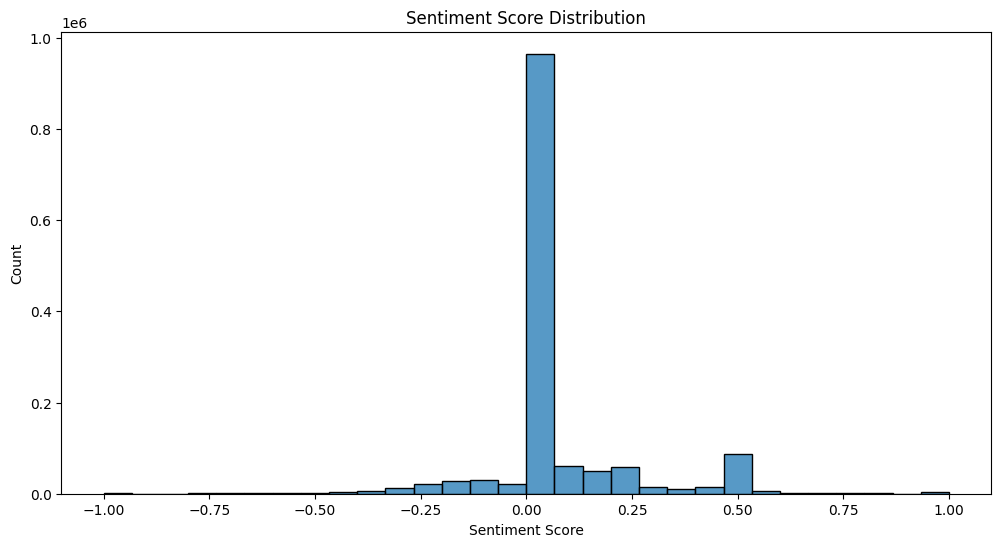

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(
    news_df["Sentiment"],
    bins=30
)

plt.title(
    "Sentiment Score Distribution"
)

plt.xlabel("Sentiment Score")

plt.show()

# Daily Average Sentiment

In [12]:
daily_sentiment = (
    news_df.groupby("Date_Only")
    ["Sentiment"]
    .mean()
    .reset_index()
)

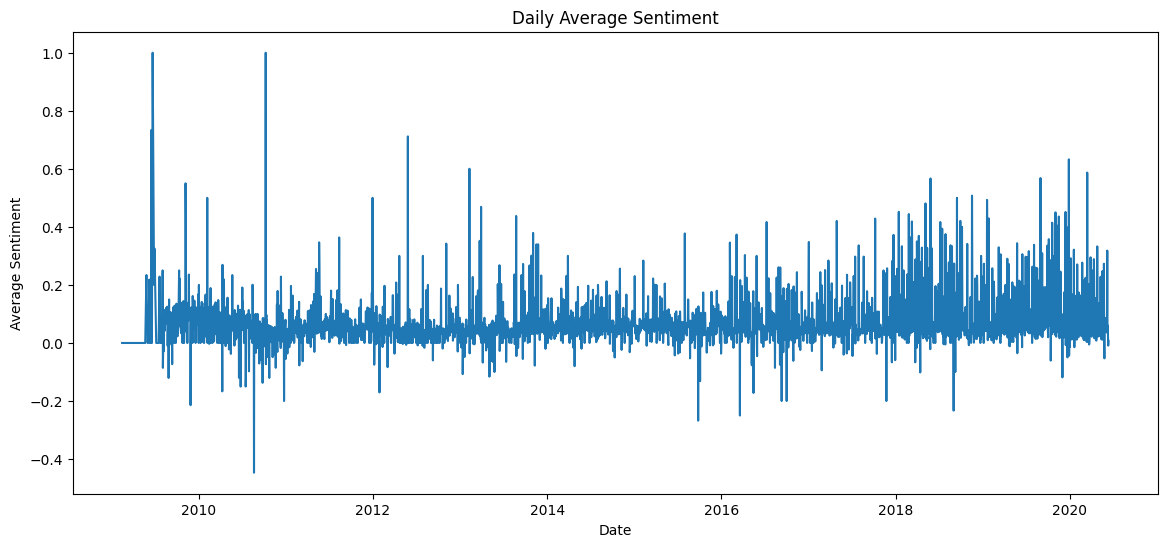

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sentiment["Date_Only"],
    daily_sentiment["Sentiment"]
)

plt.title(
    "Daily Average Sentiment"
)

plt.xlabel("Date")

plt.ylabel("Average Sentiment")

plt.show()

# Multi-Company Correlation Analysis

In [23]:
stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

In [24]:
correlation_results = []

In [25]:
for stock in stocks:

    stock_df = pd.read_csv(
        f"../Data/{stock}.csv"
    )

    stock_df["Date"] = pd.to_datetime(
        stock_df["Date"]
    )

    stock_df = stock_df.dropna()

    stock_df["Daily_Return"] = (
        stock_df["Close"].pct_change()
    )

    stock_df["Date_Only"] = (
        stock_df["Date"].dt.date
    )

    merged_df = pd.merge(
        daily_sentiment,
        stock_df,
        on="Date_Only"
    )

    correlation = (
        merged_df["Sentiment"]
        .corr(
            merged_df["Daily_Return"]
        )
    )

    correlation_results.append(
        {
            "Stock": stock,
            "Correlation": correlation
        }
    )

In [26]:
correlation_df = pd.DataFrame(
    correlation_results
)

In [27]:
correlation_df

,Stock,Correlation
0,AAPL,0.043939
1,AMZN,0.005832
2,GOOG,0.017346
3,META,0.081597
4,NVDA,-0.026399


# Correlation Comparison Across Companies

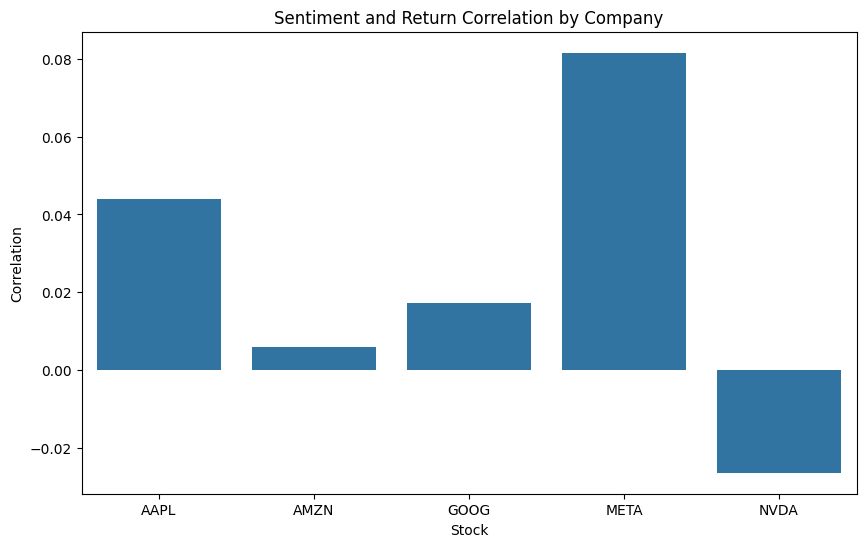

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=correlation_df,
    x="Stock",
    y="Correlation"
)

plt.title(
    "Sentiment and Return Correlation by Company"
)

plt.ylabel("Correlation")

plt.show()

# Load AAPL Stock Data

In [15]:
stock_df = pd.read_csv(
    "../Data/AAPL.csv"
)

In [16]:
stock_df["Date"] = pd.to_datetime(
    stock_df["Date"]
)

stock_df = stock_df.dropna()

# Daily Stock Returns

In [17]:
stock_df["Daily_Return"] = (
    stock_df["Close"].pct_change()
)

In [18]:
stock_df["Date_Only"] = (
    stock_df["Date"].dt.date
)

# Merge Sentiment and Stock Data

In [19]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    on="Date_Only"
)

In [20]:
merged_df.head()

,Date_Only,Sentiment,Date,Close,High,Low,Open,Volume,Daily_Return
0,2009-04-27,0.000000,2009-04-27,3.740782,3.748880,3.678701,3.685899,480690000,0.006699
1,2009-04-29,0.000000,2009-04-29,3.753081,3.804365,3.713793,3.744384,458110800,0.010008
2,2009-05-22,0.000000,2009-05-22,3.673902,3.724287,3.651409,3.720388,297998400,-0.013529
3,2009-05-27,0.234091,2009-05-27,3.990310,4.048192,3.926129,3.952221,646422000,0.017358
4,2009-05-29,0.068182,2009-05-29,4.073082,4.075781,4.014300,4.060486,456534400,0.005479


# Correlation Between Sentiment and Returns

In [21]:
correlation = (
    merged_df["Sentiment"]
    .corr(
        merged_df["Daily_Return"]
    )
)

print("Correlation:", correlation)

Correlation: 0.043939250895886996


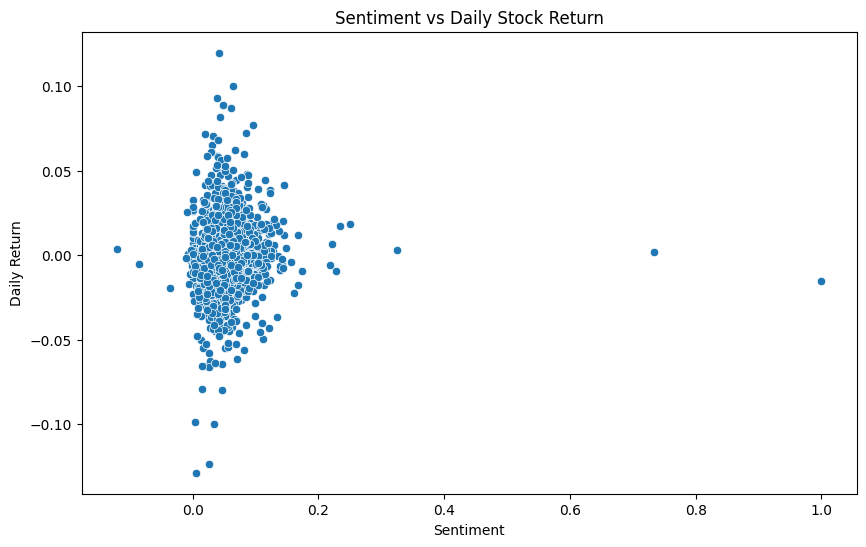

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=merged_df["Sentiment"],
    y=merged_df["Daily_Return"]
)

plt.title(
    "Sentiment vs Daily Stock Return"
)

plt.xlabel("Sentiment")

plt.ylabel("Daily Return")

plt.show()

# Key Findings

- Financial news sentiment was extracted from headlines using TextBlob.
- Daily sentiment scores were aggregated and aligned with stock market dates.
- Correlation analysis was performed between sentiment and stock returns.
- Visual analysis demonstrated relationships between news sentiment and market performance.
- The notebook combined NLP techniques with quantitative financial analysis.